# Damage detection

YOLO training + severity from box areas (`none` / `minor` / `severe`).


In [3]:
from pathlib import Path
import sys

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

DATASET_DIR = ROOT / "data"
DATA_YAML = DATASET_DIR / "data.yaml"
RUN_NAME = "ripeye"
WEIGHTS = ROOT / "runs/detect" / RUN_NAME / "weights" / "best.pt"

assert DATA_YAML.exists(), f"Missing {DATA_YAML} — see data/README.md"
print(DATASET_DIR)


/Users/cha/CS/CS180/RipEye/data


## 1. Dependencies

In [4]:
%pip install -q ultralytics pandas pyyaml matplotlib seaborn scikit-learn



Note: you may need to restart the kernel to use updated packages.


## 2. Explore dataset

Classes: ['Damaged', 'package']
  train: 2341 images
  valid: 263 images

Boxes per class (train):
  Damaged: 2633
  package: 2354


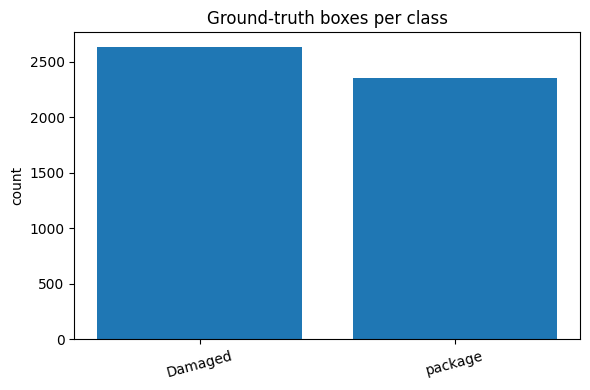

In [5]:
import yaml
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

meta = yaml.safe_load(DATA_YAML.read_text())
class_names = meta.get("names", [])
if isinstance(class_names, dict):
    class_names = [class_names[k] for k in sorted(class_names, key=int)]

print("Classes:", class_names)
for split in ("train", "valid", "test"):
    img_dir = DATASET_DIR / split / "images"
    if img_dir.exists():
        n = len(list(img_dir.glob("*")))
        print(f"  {split}: {n} images")

# Bbox class counts from YOLO labels
box_counts = Counter()
labels_dir = DATASET_DIR / "train" / "labels"
for lf in labels_dir.glob("*.txt"):
    for line in lf.read_text().strip().splitlines():
        if line.strip():
            box_counts[int(line.split()[0])] += 1

print("\nBoxes per class (train):")
for cid, count in sorted(box_counts.items()):
    name = class_names[cid] if cid < len(class_names) else str(cid)
    print(f"  {name}: {count}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([class_names[i] for i in sorted(box_counts)], [box_counts[i] for i in sorted(box_counts)])
ax.set_title("Ground-truth boxes per class")
ax.set_ylabel("count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



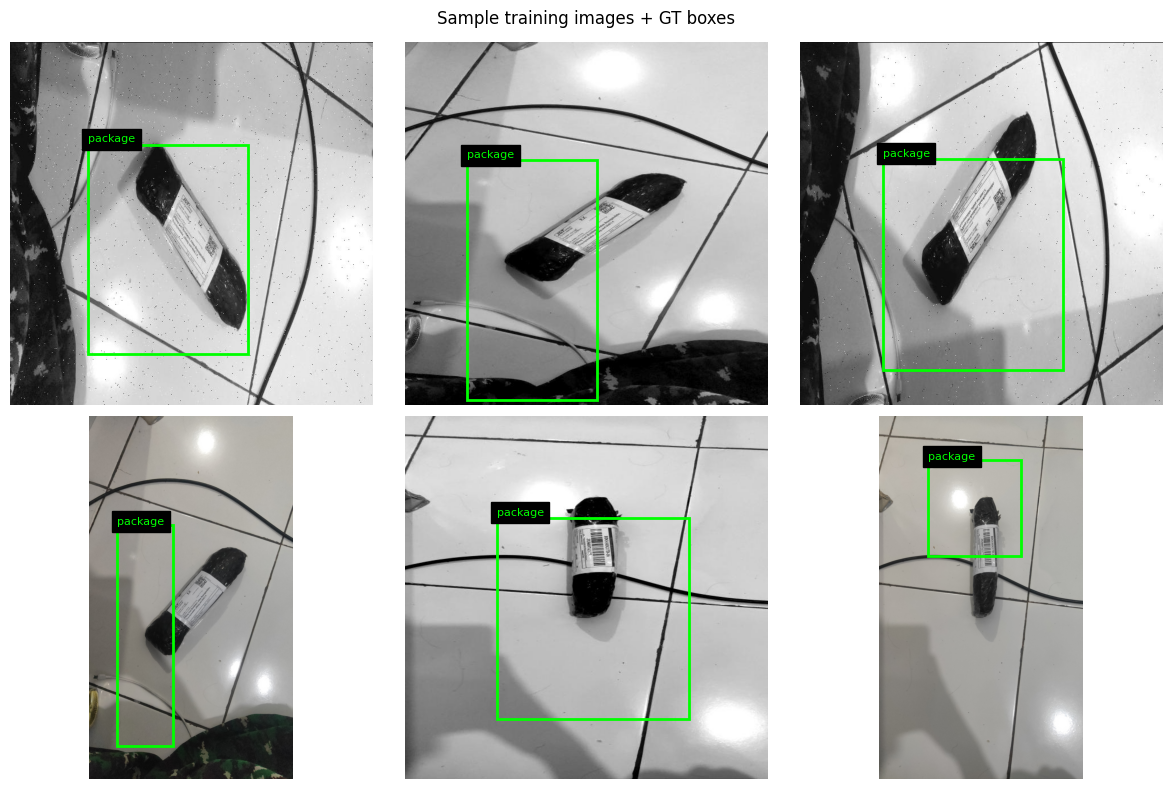

In [6]:
# Sample images with boxes (first 6)
from PIL import Image
import matplotlib.patches as patches

def draw_sample(stem: str, ax):
    img_path = next((DATASET_DIR / "train" / "images").glob(f"{stem}.*"), None)
    label_path = DATASET_DIR / "train" / "labels" / f"{stem}.txt"
    if not img_path or not label_path.exists():
        ax.axis("off")
        return
    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)
    ax.axis("off")
    for line in label_path.read_text().strip().splitlines():
        p = line.split()
        if len(p) < 5:
            continue
        cid, xc, yc, bw, bh = int(p[0]), *map(float, p[1:5])
        x1 = (xc - bw / 2) * w
        y1 = (yc - bh / 2) * h
        rect = patches.Rectangle((x1, y1), bw * w, bh * h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, class_names[cid], color="lime", fontsize=8, backgroundcolor="black")

stems = [p.stem for p in sorted(labels_dir.glob("*.txt"))[:6]]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, stem in zip(axes.flat, stems):
    draw_sample(stem, ax)
fig.suptitle("Sample training images + GT boxes")
plt.tight_layout()
plt.show()



## 3. Config

In [13]:
from ripeye.severity import SeverityConfig
from ultralytics import YOLO

CFG = SeverityConfig(minor_ratio=0.05, severe_ratio=0.20)
EPOCHS_MAX = 100  # upper cap; training stops early if val mAP plateaus
PATIENCE = 15     # stop after this many epochs with no val improvement
IMG_SIZE = 640
MODEL_CKPT = "yolov8s.pt"
PREDICT_CONF = 0.15
EVAL_SPLIT = 0.2
RANDOM_STATE = 42


## 4. Severity labels (ground truth)

In [14]:
import pandas as pd
from ripeye.severity import build_severity_csv

csv_path = DATASET_DIR / "severity_labels.csv"
build_severity_csv(DATASET_DIR, csv_path, cfg=CFG)
df = pd.read_csv(csv_path)
print(df["severity"].value_counts())
df.head(8)



severity
none      1349
minor      835
severe     420
Name: count, dtype: int64


,label_file,damage_area_ratio,severity,num_boxes,has_severe_box,split,image_stem
0,train/labels/IMG20250819191934_jpg.rf.19d5e4e8...,0.0,none,1,False,train,IMG20250819191934_jpg.rf.19d5e4e8667dd260b0fdd...
1,train/labels/IMG20250819191934_jpg.rf.3ffee74a...,0.0,none,1,False,train,IMG20250819191934_jpg.rf.3ffee74aaac6a525faa25...
2,train/labels/IMG20250819191934_jpg.rf.510d4ee2...,0.0,none,1,False,train,IMG20250819191934_jpg.rf.510d4ee28234b8fb37eda...
3,train/labels/IMG20250819191934_jpg.rf.f79mzxPc...,0.0,none,1,False,train,IMG20250819191934_jpg.rf.f79mzxPcvE0ispSQehCt
4,train/labels/IMG20250819191938_jpg.rf.2f6a2abc...,0.0,none,1,False,train,IMG20250819191938_jpg.rf.2f6a2abccb08932b57fdc...
5,train/labels/IMG20250819191938_jpg.rf.EpMdZTfH...,0.0,none,1,False,train,IMG20250819191938_jpg.rf.EpMdZTfHf0MX35o6EgSw
6,train/labels/IMG20250819191938_jpg.rf.c1f09812...,0.0,none,1,False,train,IMG20250819191938_jpg.rf.c1f09812ef17f92e618ff...
7,train/labels/IMG20250819191938_jpg.rf.cc7de490...,0.0,none,1,False,train,IMG20250819191938_jpg.rf.cc7de4906491077e50727...


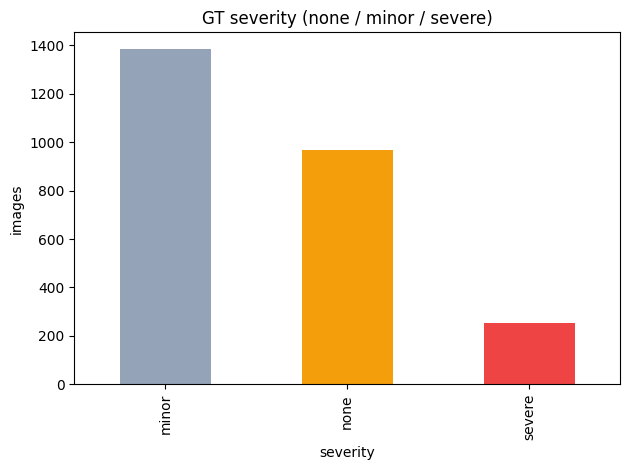

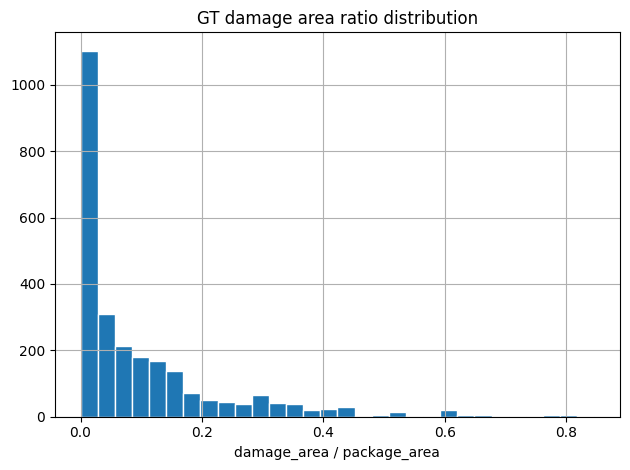

In [58]:
df["severity"].value_counts().plot.bar(
    title="GT severity (none / minor / severe)", color=["#94a3b8", "#f59e0b", "#ef4444"]
)
plt.ylabel("images")
plt.tight_layout()
plt.show()

df["damage_area_ratio"].hist(bins=30, edgecolor="white")
plt.title("GT damage area ratio distribution")
plt.xlabel("damage_area / package_area")
plt.tight_layout()
plt.show()



## 5. Train object detector (YOLO)

In [ ]:
import torch

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", DEVICE)

model = YOLO(MODEL_CKPT)
train_results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS_MAX,
    patience=PATIENCE,
    imgsz=IMG_SIZE,
    device=DEVICE,
    cache=True,
    project=str(ROOT / "runs/detect"),
    name=RUN_NAME,
    exist_ok=True,
)
best = YOLO(str(WEIGHTS)) if WEIGHTS.exists() else model
print("Weights:", WEIGHTS)
print("Stopped at epoch:", train_results.epoch if hasattr(train_results, "epoch") else "see results.csv")


Device: mps
Ultralytics 8.4.52 🚀 Python-3.13.7 torch-2.12.0 MPS (Apple M1 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/cha/CS/CS180/RipEye/data/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ripeye, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

## 6. Detection metrics (mAP)

Ultralytics 8.4.52 🚀 Python-3.13.7 torch-2.12.0 CPU (Apple M1 Pro)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 107.1±36.4 MB/s, size: 42.5 KB)
val: Scanning /Users/cha/CS/CS180/RipEye/data/valid/labels.cache... 263 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 263/263 20.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 5.9s/it 1:406.2ss
                   all        263        559      0.964      0.894      0.953      0.733
               Damaged        190        292      0.931      0.788      0.912      0.538
               package        263        267      0.997          1      0.995      0.928
Speed: 1.1ms preprocess, 376.3ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /Users/cha/CS/CS180/RipEye/runs/detect/val-4
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index:

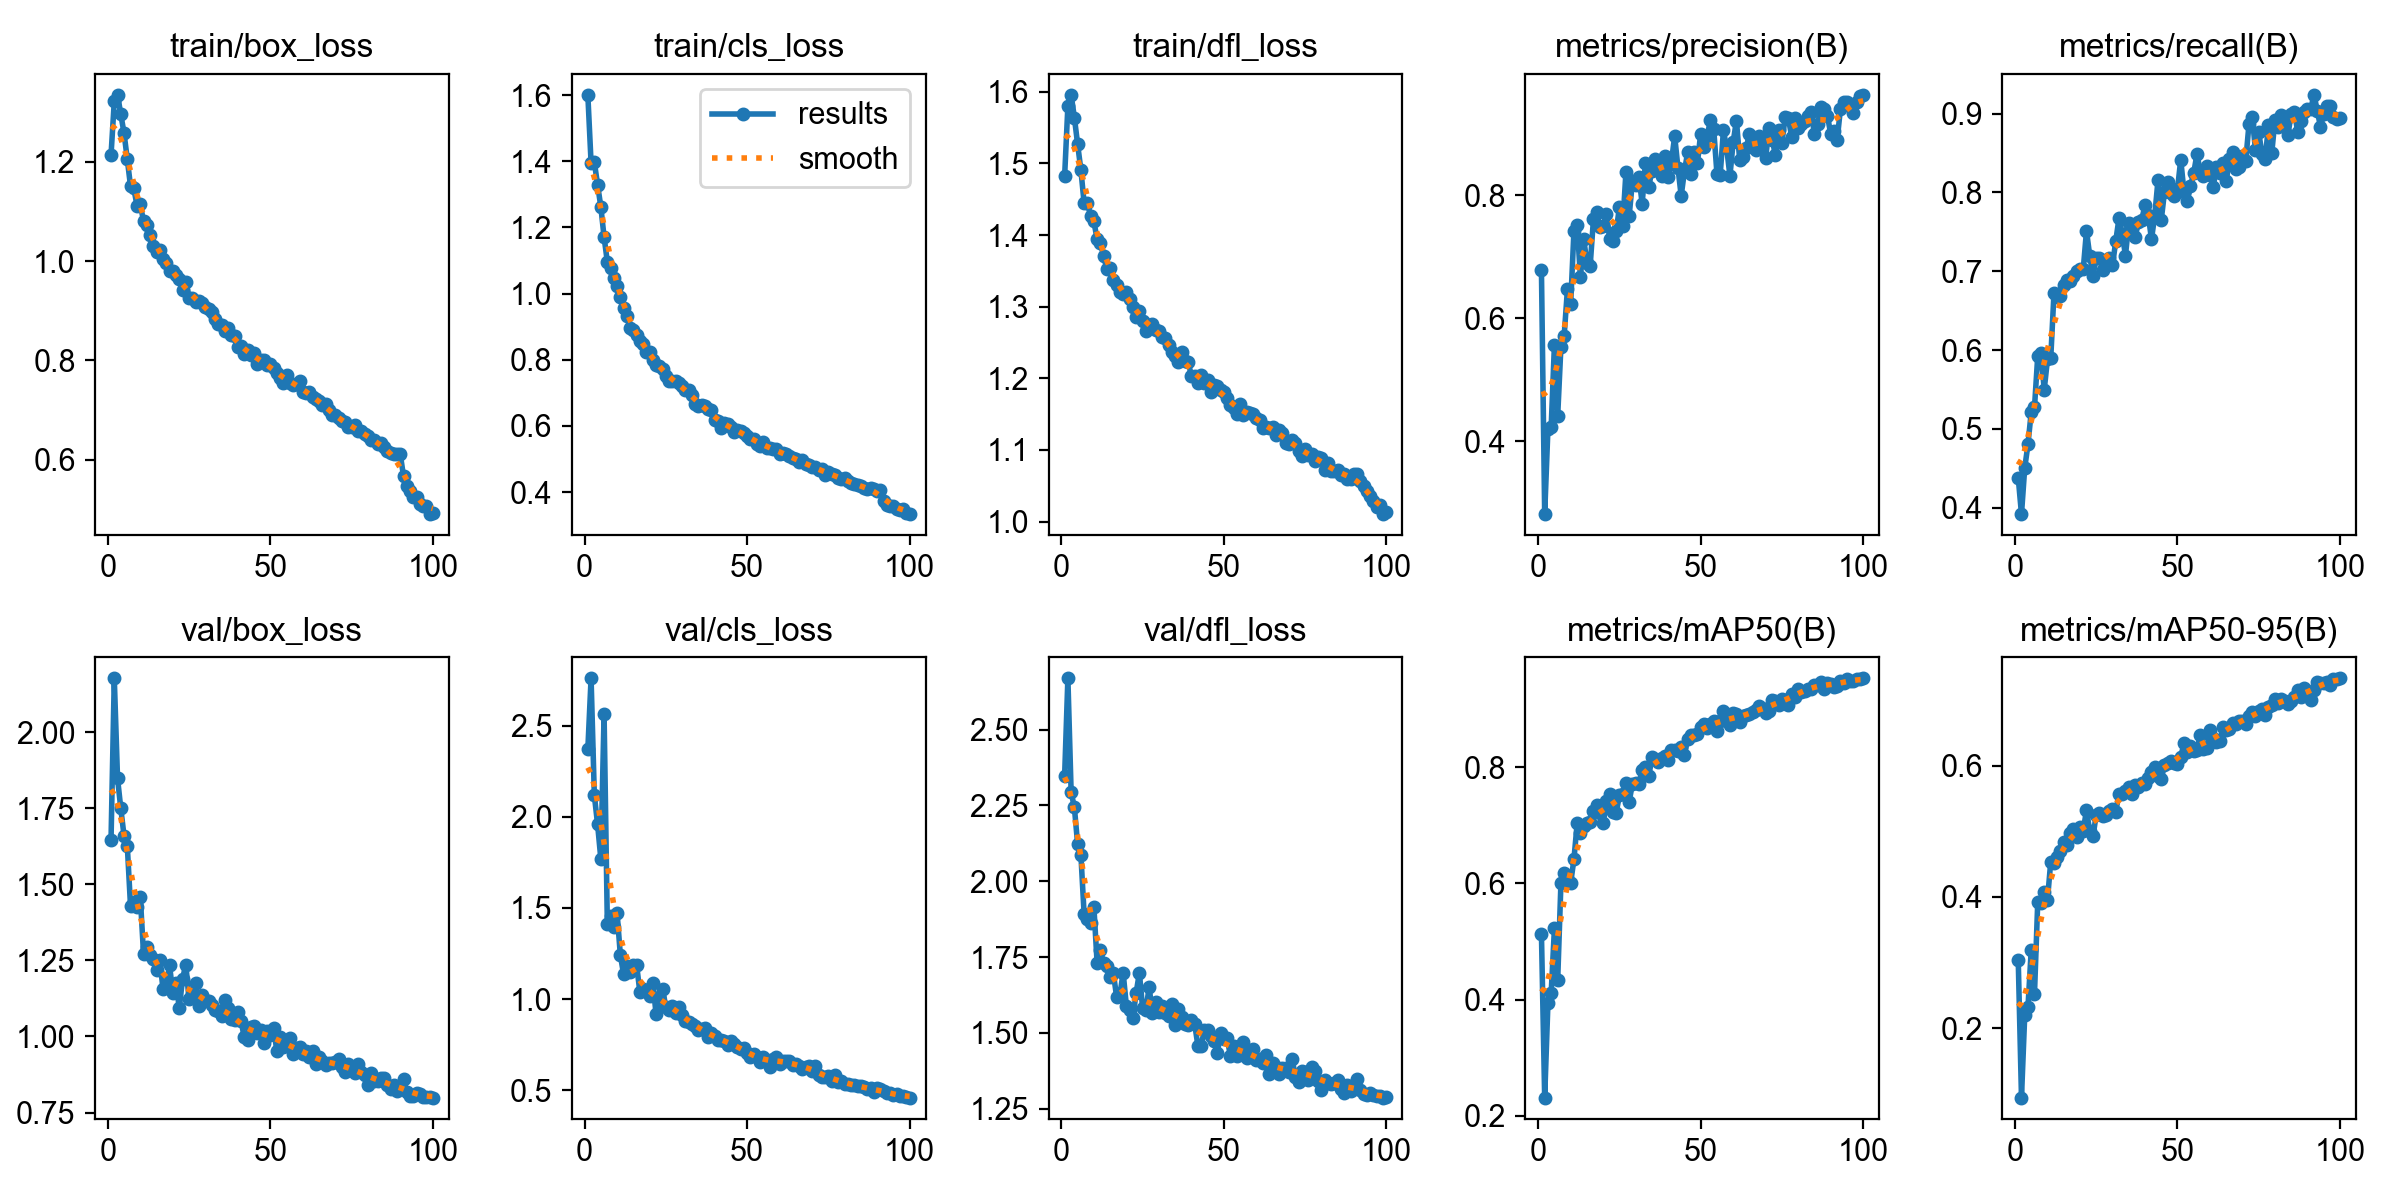

confusion_matrix.png


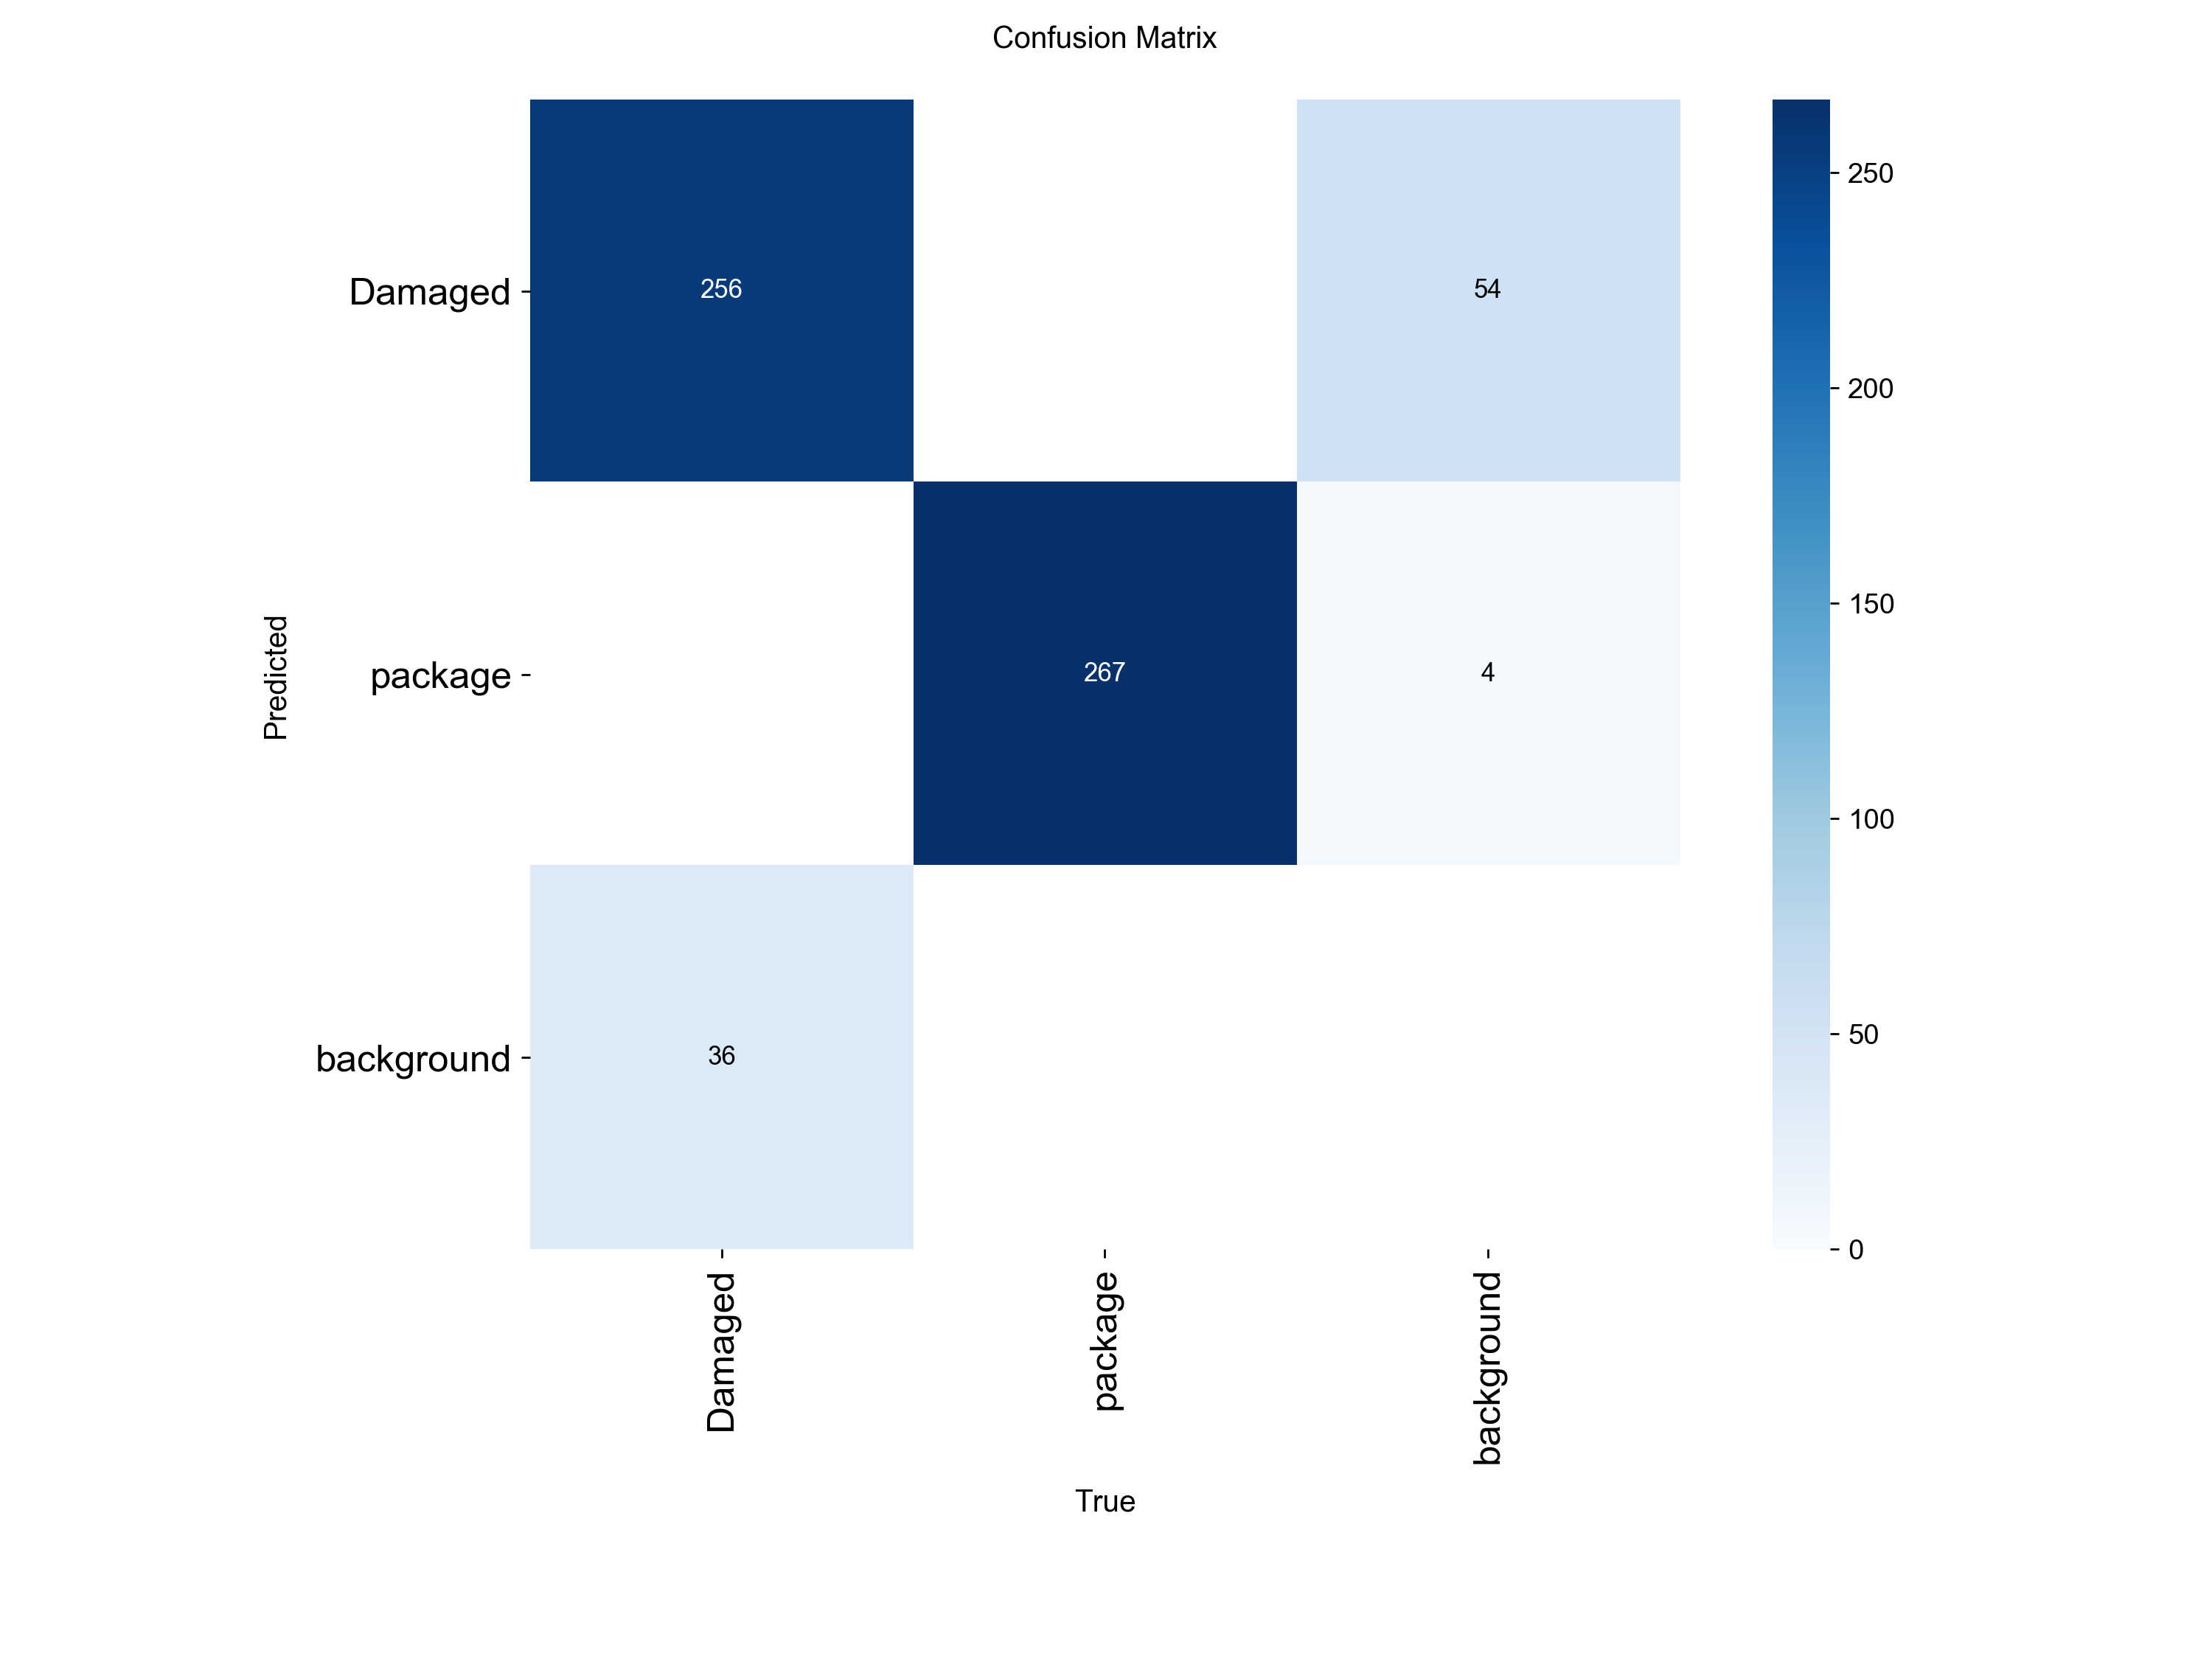

BoxF1_curve.png


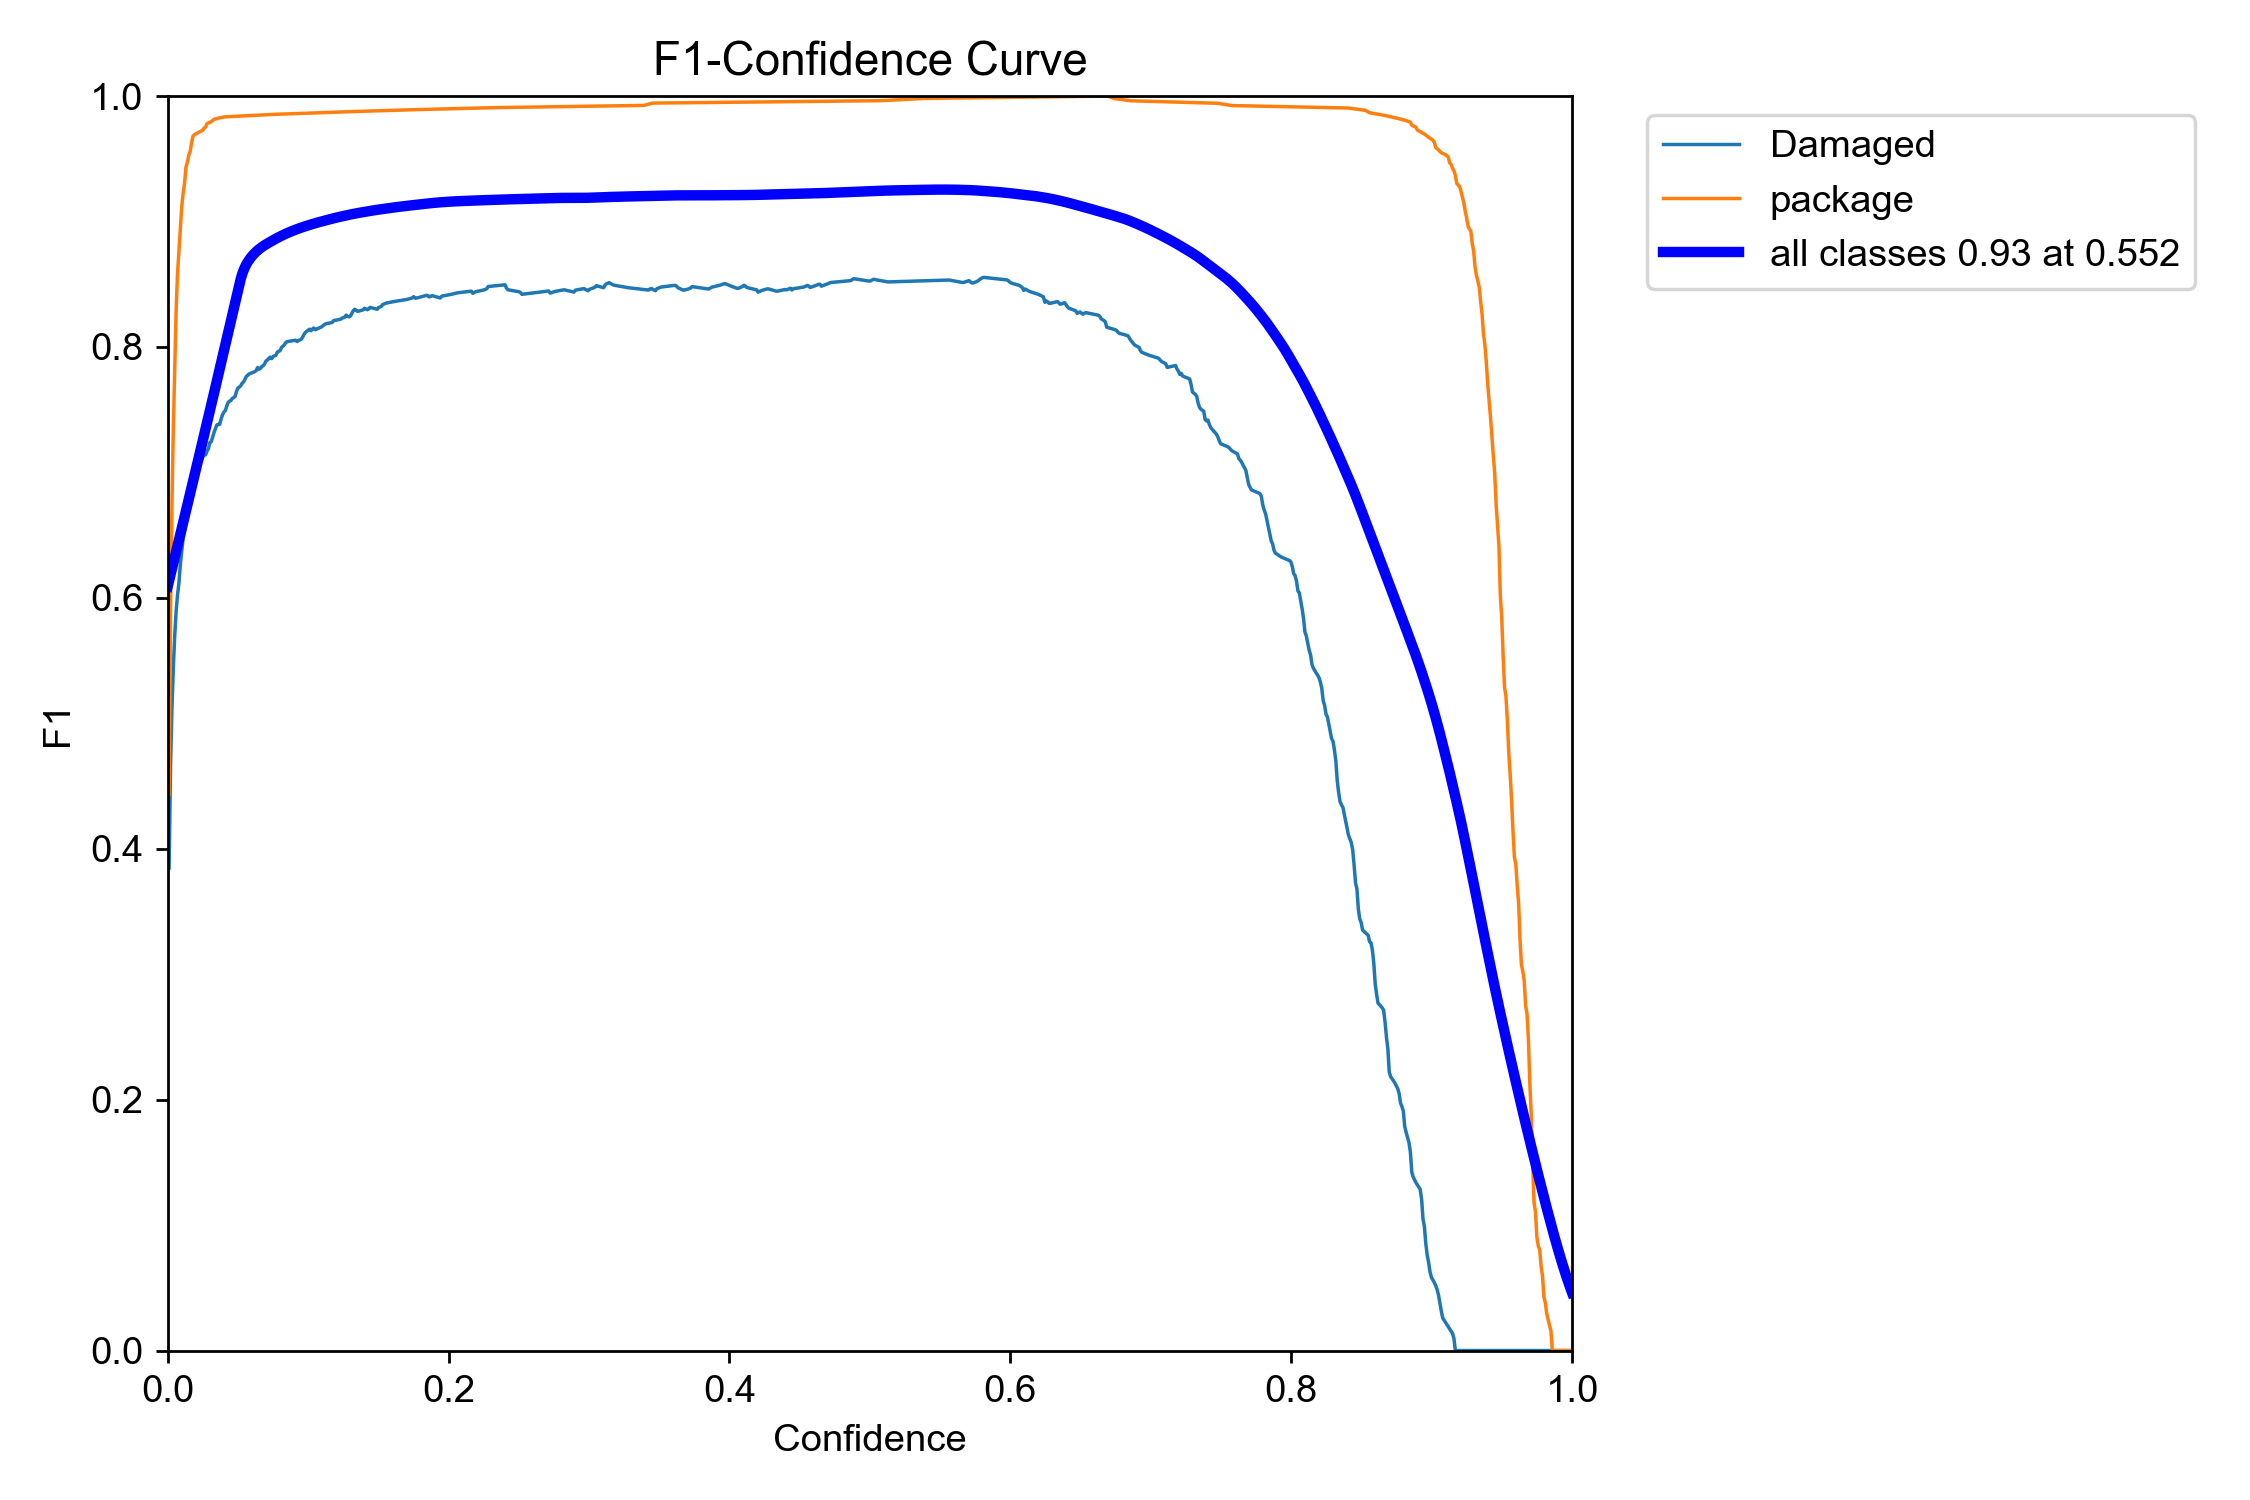

In [19]:
best = YOLO(str(WEIGHTS)) if WEIGHTS.exists() else YOLO(MODEL_CKPT)
det_metrics = best.val(data=str(DATA_YAML))
print(det_metrics)
# Training curves are saved under runs/detect/ripeye/
from IPython.display import Image as IPImage, display
for name in ("results.png", "confusion_matrix.png", "BoxF1_curve.png"):
    p = ROOT / "runs/detect" / RUN_NAME / name
    if p.exists():
        print(name)
        display(IPImage(filename=str(p)))


## 7. Severity accuracy (predicted boxes → none/minor/severe)

Eval on Roboflow valid split: 263 images

Severity accuracy (holdout): 0.825
              precision    recall  f1-score   support

        none       0.92      0.83      0.88       126
       minor       0.87      0.80      0.83        98
      severe       0.58      0.87      0.69        39

    accuracy                           0.83       263
   macro avg       0.79      0.83      0.80       263
weighted avg       0.85      0.83      0.83       263



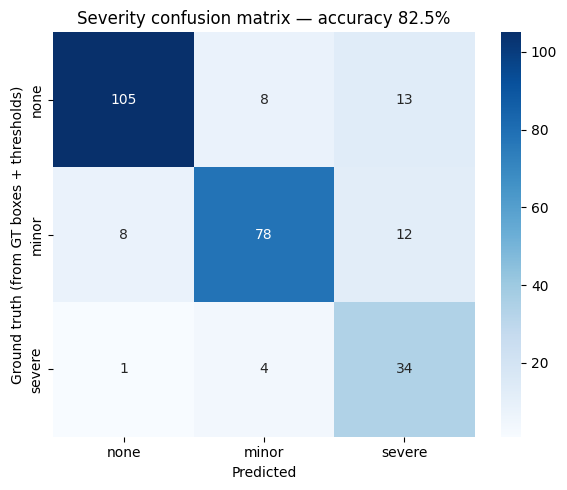

In [20]:
best = YOLO(str(WEIGHTS)) if WEIGHTS.exists() else YOLO(MODEL_CKPT)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from ripeye.severity import load_id_to_name, severity_for_prediction

id_to_name = load_id_to_name(DATA_YAML)

valid_dir = DATASET_DIR / "valid" / "images"
if valid_dir.exists() and any(valid_dir.iterdir()):
    eval_df = df[df["split"] == "val"].copy()
    if eval_df.empty:
        eval_df = df[df["label_file"].str.startswith("valid/")].copy()
    img_roots = [valid_dir]
    print(f"Eval on Roboflow valid split: {len(eval_df)} images")
else:
    eval_df, _ = train_test_split(
        df,
        test_size=EVAL_SPLIT,
        random_state=RANDOM_STATE,
        stratify=df["severity"],
    )
    img_roots = [DATASET_DIR / "train" / "images"]
    print(f"Holdout eval: {len(eval_df)} images ({EVAL_SPLIT:.0%} of {len(df)})")

y_true, y_pred = [], []

for _, row in eval_df.iterrows():
    stem = row["image_stem"]
    img_path = None
    for root in img_roots:
        img_path = next(root.glob(f"{stem}.*"), None)
        if img_path:
            break
    if not img_path:
        img_path = next((DATASET_DIR / "train" / "images").glob(f"{stem}.*"), None)
    if not img_path:
        continue
    results = best.predict(str(img_path), imgsz=IMG_SIZE, conf=PREDICT_CONF, verbose=False)
    pred = severity_for_prediction(results[0], id_to_name, cfg=CFG)
    y_true.append(row["severity"])
    y_pred.append(pred["severity"])

labels = ["none", "minor", "severe"]
acc = accuracy_score(y_true, y_pred)
print(f"\nSeverity accuracy (holdout): {acc:.3f}")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Ground truth (from GT boxes + thresholds)")
ax.set_title(f"Severity confusion matrix — accuracy {acc:.1%}")
plt.tight_layout()
plt.show()
